# Working with BOSS-CLAM Stellar Parameters

## Learning Goals

By the end of this tutorial, you will:
- Load stellar parameters inferred using BOSS-CLAM
- Filter BOSS-CLAM data based on flags and targeting meta-data
- Compare observed spectra to BOSS-CLAM forward modeled spectra
- Plot stellar parameters from BOSS-CLAM

## Introduction

The CLAM (Constrained Linear Absorption Model) is a constrained linear absorption model that simultaneously fits stellar absorption and continuum via non-negative matrix factorization [(Casey et al. 2026)](https://ui.adsabs.harvard.edu/abs/2026ApJ...998..192C/abstract). "BOSS-CLAM" is for the implementation of a similar method. Here, BOSS-CLAM also seeks to decompose stellar spectra using non-negative matrix factorization (NMF), but additionally optimizes a mapping between the NMF weights and stellar labels. Once the model is trained, this allows us to infer stellar labels from observed spectra.

BOSS-CLAM was trained on BOSS continuum-normalized spectra from SDSS-V DR20, and these parameters and forward modeled spectra are released as a value added catalog (VAC). This tutorial will demonstrate how to load this VAC and work with these data.


## Imports

This tutorial requires:
- *numpy* for doing large array operations
- *matplotlib* for plotting
- *astropy* for coordinate conversions
- *h5py* for reading VAC file
- *sdss_access*
- *sdss_semaphore*
  
Missing packages can be installed via `pip install numpy matplotlib astropy h5py sdss-access sdss-semaphore`

In [1]:
import os

import numpy as np
import h5py

from astropy import units as u
from astropy.coordinates import SkyCoord
import astropy.coordinates as coord
from astropy.io import fits

import warnings
warnings.filterwarnings('ignore')

import sdss_access
from sdss_semaphore.targeting import TargetingFlags

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm
%matplotlib inline

plt.rcParams.update({'figure.facecolor': 'white',
                      'savefig.facecolor': 'white',
                      'font.size': 24,
                      'xtick.labelsize': 24,
                      'ytick.labelsize': 24,
                      'errorbar.capsize': 2})

## Loading data from HDF5 file

The main version of the VAC is stored in a HDF5 format. This is because the VAC included stellar parameters and forward modeled spectra. This format allows these added data, along with all targeting meta-data, to be stored in one file. Additionally, when opening an HDF5 file, the data is not loaded into memory until it is indexed.

Below we will open the instance of the file and shows the keys for the two main groups.

<div class="alert alert-block alert-warning">
<b>Warning:</b> The full BOSS-CLAM file is large, 25 GB. This cell will download the full file if run on your computer. Consider running this tutorial in a SciServer environment. 
</div>

You can also use the lite version of the file for many use cases by changing the `sdss-access` lines to `('boss_clam_lite', v_vac='1.0.0', ftype="h5")` (or `ftype="fits"` if you want a fits file for your own purposes, but this tutorial requires h5), but the lite version of the file does not include the "forward_model_flux" information which is needed for this tutorial.

In [2]:
sdss_path = sdss_access.path.Path(release='dr20', verbose=True)
access = sdss_access.Access(release='dr20', verbose=True)

vac_file = sdss_path.full('boss_clam_params', v_vac='1.0.0')

if not sdss_path.exists('',full=vac_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('boss_clam_params', v_vac='1.0.0')
    access.set_stream()
    access.commit()
    vac_file = sdss_path.full('boss_clam_params', v_vac='1.0.0')
    

res = h5py.File(vac_file, 'r')

for group in res.keys():
    print(group)
    for dset in res[group].keys():
        print(f'\t{dset}: shape {res[group][dset].shape}')

clam
	alpha_m: shape (1708214,)
	clam_flags: shape (1708214,)
	fe_h: shape (1708214,)
	flag_bad: shape (1708214,)
	flag_warn: shape (1708214,)
	forward_model_flux: shape (1708214, 4648)
	logg: shape (1708214,)
	param_covariance: shape (1708214, 4, 4)
	rchi2: shape (1708214,)
	teff: shape (1708214,)
meta
	apogee_max_mjd: shape (1708214,)
	apogee_min_mjd: shape (1708214,)
	b: shape (1708214,)
	b_jkc_mag: shape (1708214,)
	b_jkc_mag_flag: shape (1708214,)
	bailer_jones_flags: shape (1708214,)
	bl_flg: shape (1708214,)
	boss_max_mjd: shape (1708214,)
	boss_min_mjd: shape (1708214,)
	bp_mag: shape (1708214,)
	c_star: shape (1708214,)
	catalogid: shape (1708214,)
	catalogid21: shape (1708214,)
	catalogid25: shape (1708214,)
	catalogid31: shape (1708214,)
	cc_flg: shape (1708214,)
	created: shape (1708214,)
	crossmatch_flags: shape (1708214,)
	csf: shape (1708214,)
	d4_5m: shape (1708214,)
	dec: shape (1708214,)
	e_ebv: shape (1708214,)
	e_ebv_bayestar_2019: shape (1708214,)
	e_ebv_edenhofer_

## Plotting Stellar Parameters

With this file, we can now plot the stellar parameters from BOSS-CLAM. There are two important flags for cleaning the dataset. If only working the `teff` and `logg`, then it is recommended to only include sources where `flag_bad = False`. If also working with `fe_h` and/or `alpha_m`m then it is recommended to only include sources where `clam_flags = 0`.

Below we will plot a Kiel diagram and [$\alpha$/M] vs. [Fe/H] for the VAC with these cuts.

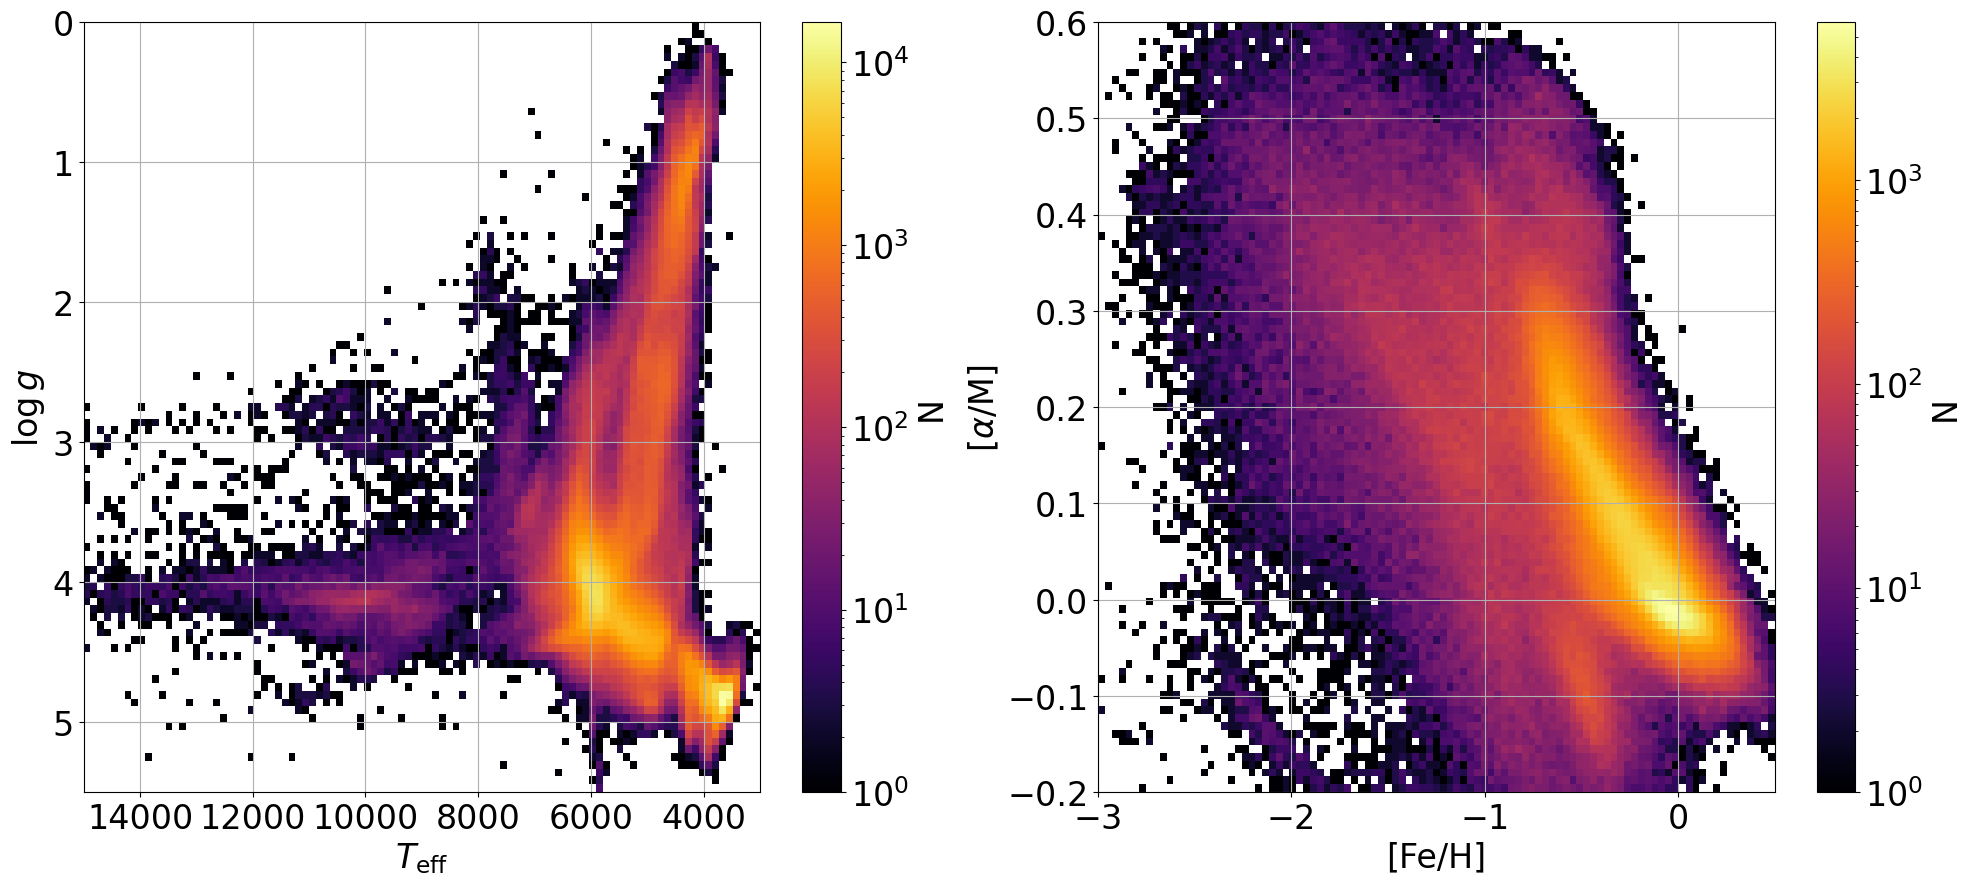

In [3]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

xbins = np.linspace(3000, 15000, 100)
ybins = np.linspace(0, 5.5, 100)

clean = ~res['clam']['flag_bad'][:]
resp = ax1.hist2d(res['clam']['teff'][clean], res['clam']['logg'][clean],
                 bins=[xbins, ybins], norm=LogNorm(), cmap='inferno')
plt.colorbar(resp[-1], label='N', ax=ax1)
ax1.invert_xaxis()
ax1.invert_yaxis()
ax1.grid()
ax1.set_xlabel(r'$T_\mathrm{eff}$')
ax1.set_ylabel('$\log g$')

xbins = np.linspace(-3, 0.5, 100)
ybins = np.linspace(-0.2, 0.6, 100)

clean = res['clam']['clam_flags'][:] == 0
resp = ax2.hist2d(res['clam']['fe_h'][clean], res['clam']['alpha_m'][clean],
                 bins=[xbins, ybins], norm=LogNorm(), cmap='inferno')
plt.colorbar(resp[-1], label='N', ax=ax2)
ax2.grid()
ax2.set_xlabel(r'[Fe/H]')
ax2.set_ylabel(r'[$\alpha$/M]')

plt.show()

Additionally, the VAC includes all targeting information. So, we can, for example, limit the above to just one SDSS-V program using the `sdss5_target_flags` and further filter on SNR of the spectrum. First we will load the flags into `sdss_semaphore` and then filter for objects in the Magellanic Clouds program.

In [4]:
flags = TargetingFlags(res['meta']["sdss5_target_flags"][:])

mcs = flags.in_program("mwm_magcloud")

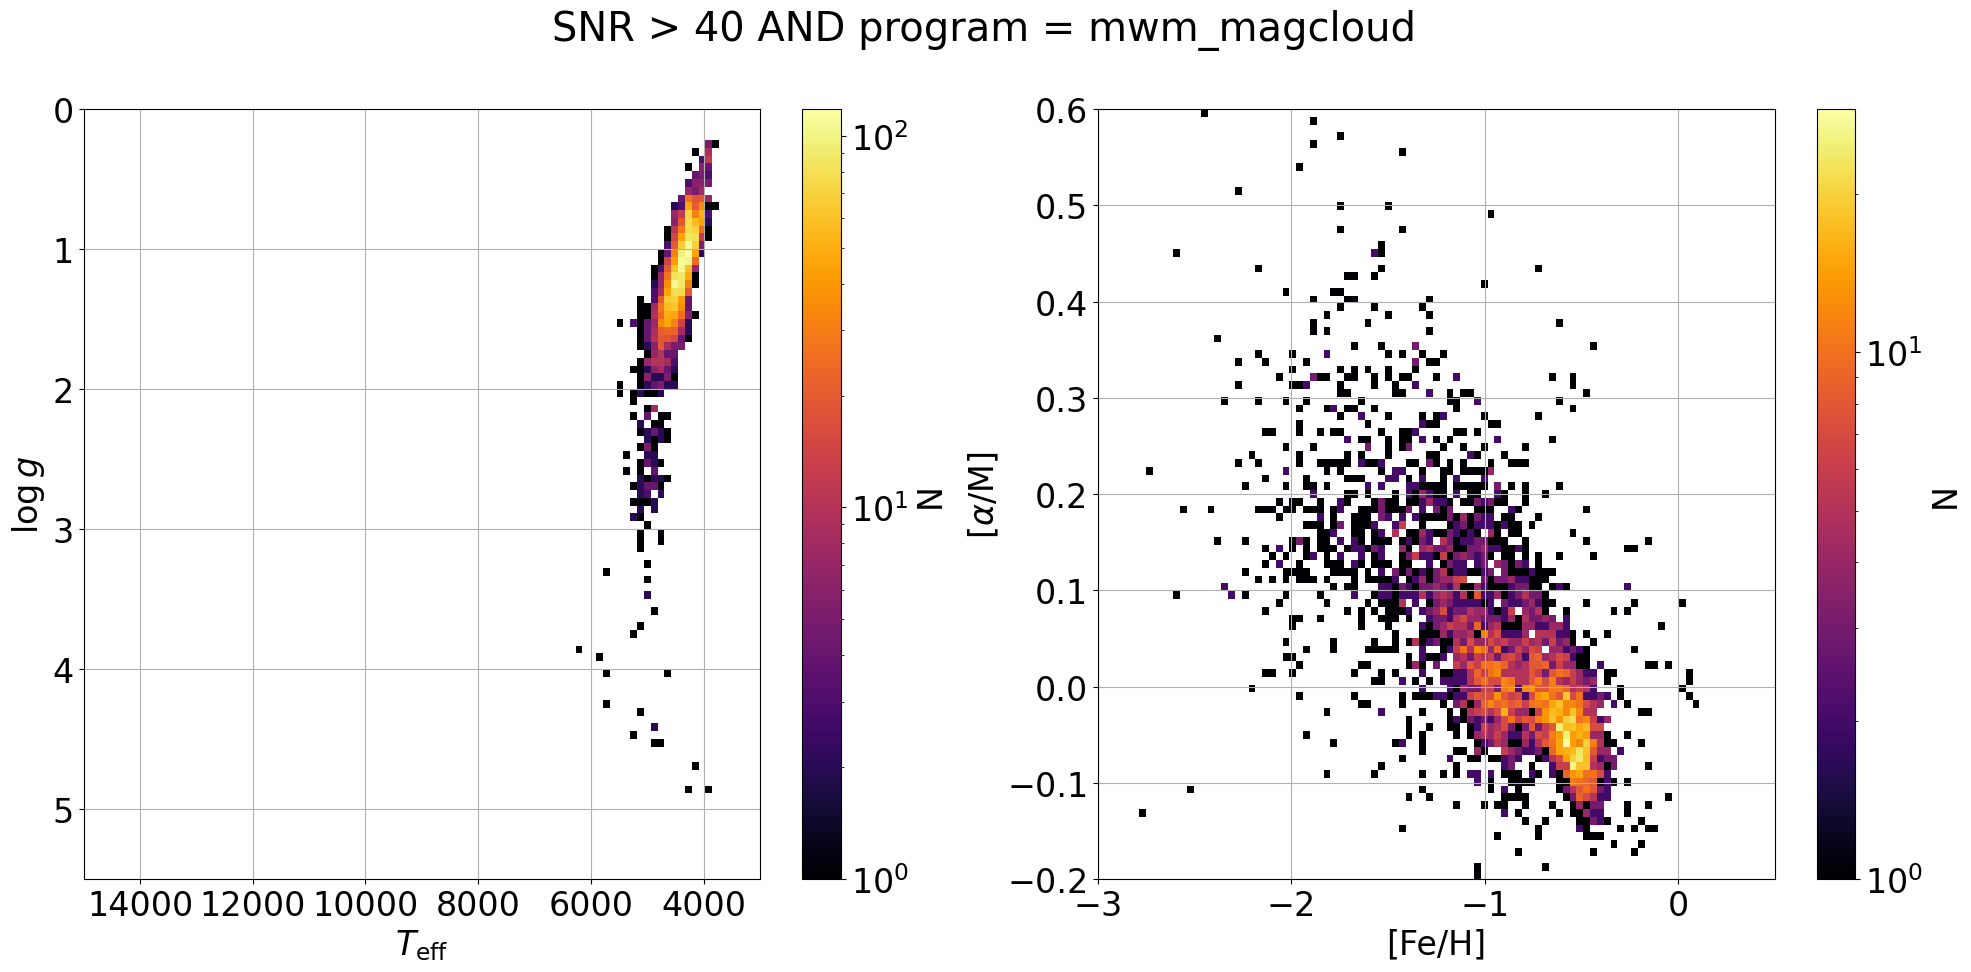

In [5]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

xbins = np.linspace(3000, 15000, 100)
ybins = np.linspace(0, 5.5, 100)

clean = ~res['clam']['flag_bad'][:] & mcs & (res['meta']['snr'][:] > 40)
resp = ax1.hist2d(res['clam']['teff'][clean], res['clam']['logg'][clean],
                 bins=[xbins, ybins], norm=LogNorm(), cmap='inferno')
plt.colorbar(resp[-1], label='N', ax=ax1)
ax1.invert_xaxis()
ax1.invert_yaxis()
ax1.grid()
ax1.set_xlabel(r'$T_\mathrm{eff}$')
ax1.set_ylabel('$\log g$')

xbins = np.linspace(-3, 0.5, 100)
ybins = np.linspace(-0.2, 0.6, 100)

clean = (res['clam']['clam_flags'][:] == 0) & mcs & (res['meta']['snr'][:] > 40)
resp = ax2.hist2d(res['clam']['fe_h'][clean], res['clam']['alpha_m'][clean],
                 bins=[xbins, ybins], norm=LogNorm(), cmap='inferno')
plt.colorbar(resp[-1], label='N', ax=ax2)
ax2.grid()
ax2.set_xlabel(r'[Fe/H]')
ax2.set_ylabel(r'[$\alpha$/M]')

plt.suptitle('SNR > 40 AND program = mwm_magcloud')

plt.show()

## Comparing Observed and Forward Modeled Spectra

BOSS-CLAM infers stellar parameters by comparing the continuum-normalized BOSS spectra to spectra forward modeled from stellar labels. This VAC includes the forward modeled spectrum that best fits the observed spectrum. Below we show how to load the observed spectrum for some `sdss_id` and compare it to the BOSS-CLAM forward modeled spectrum.

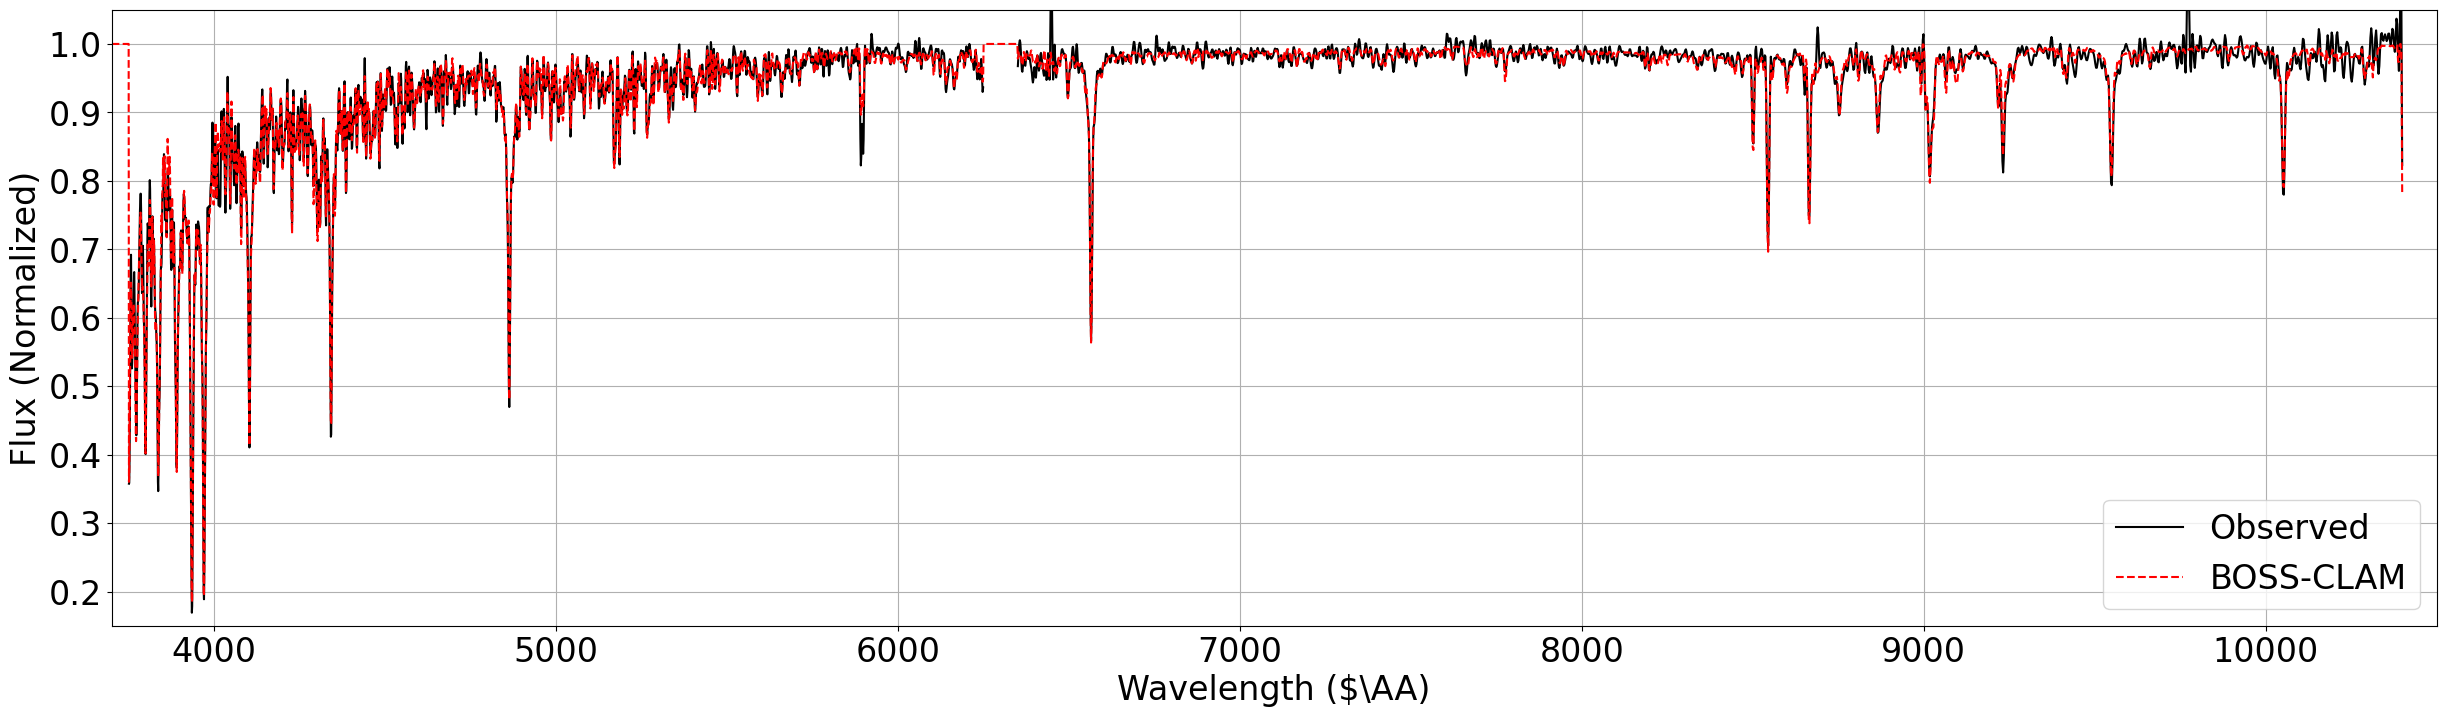

In [6]:
sdss_id = 54381198

# index with above sdss_id
idx = np.where(res['meta']['sdss_id'][:] == sdss_id)[0][0]

sdss_path = sdss_access.path.Path(release='dr20', verbose=True)
access = sdss_access.Access(release='dr20', verbose=True)

spec_file = sdss_path.full('mwmStar', sdss_id=sdss_id, v_astra='0.8.1')

if not sdss_path.exists('',full=spec_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('mwmStar', sdss_id=sdss_id, v_astra='0.8.1')
    access.set_stream()
    access.commit()
    spec_file = sdss_path.full('mwmStar', sdss_id=sdss_id, v_astra='0.8.1')

hdu = fits.open(spec_file)
if res['meta']['telescope'][idx] == 'apo25m':
    mwmStar = hdu[0].data
else:
    mwmStar = hdu[1].data

obs_wl = mwmStar["wavelength"][0]
obs_flux = mwmStar["flux"][0]
obs_cont = mwmStar["continuum"][0]


# plot the spectra
plt.figure(figsize=(30, 8))
plt.plot(obs_wl, obs_flux / obs_cont, c='k', label='Observed')
plt.plot(obs_wl, res['clam']['forward_model_flux'][idx], '--', c='r', label='BOSS-CLAM')
plt.grid()
plt.legend()
plt.ylim(0.15, 1.05)
plt.xlim(3700, 10500)
plt.xlabel('Wavelength ($\AA)')
plt.ylabel('Flux (Normalized)')
plt.show()

## BOSS-CLAM parameters throughout the Galaxy

As a final example, here we show the [$\alpha$/M] vs. [Fe/H] diagram for different cuts in Galactic radius and height. Here we use the photogeometric distances from [Bailer-Jones et al. (2021)](https://ui.adsabs.harvard.edu/abs/2021yCat.1352....0B/abstract) to convert to Galactic coordinates:

In [7]:
c = SkyCoord(ra=res['meta']['ra'][:]*u.degree,
             dec=res['meta']['dec'][:]*u.degree,
             distance=res['meta']['r_med_photogeo'][:]*u.pc,
             pm_ra_cosdec=res['meta']['pmra'][:]*u.mas/u.yr,
             pm_dec=res['meta']['pmde'][:]*u.mas/u.yr,
             radial_velocity=res['meta']['v_rad'][:]*u.km/u.s,
             frame='icrs')

gc = c.transform_to(coord.Galactocentric)
Rgc = np.sqrt(gc.x.value ** 2 + gc.y.value ** 2)
z0 = gc.z.value

ev = res['clam']['clam_flags'][:] == 0
R = Rgc[ev] / 1000
z = z0[ev] / 1000
fe_h = res['clam']['fe_h'][:][ev]
alpha_m = res['clam']['alpha_m'][:][ev]

Now let's create our plot. The cyan lines overlayed on this plot are the approximate location of the high- and low-$\alpha$ sequences in ASPCAP from DR19.

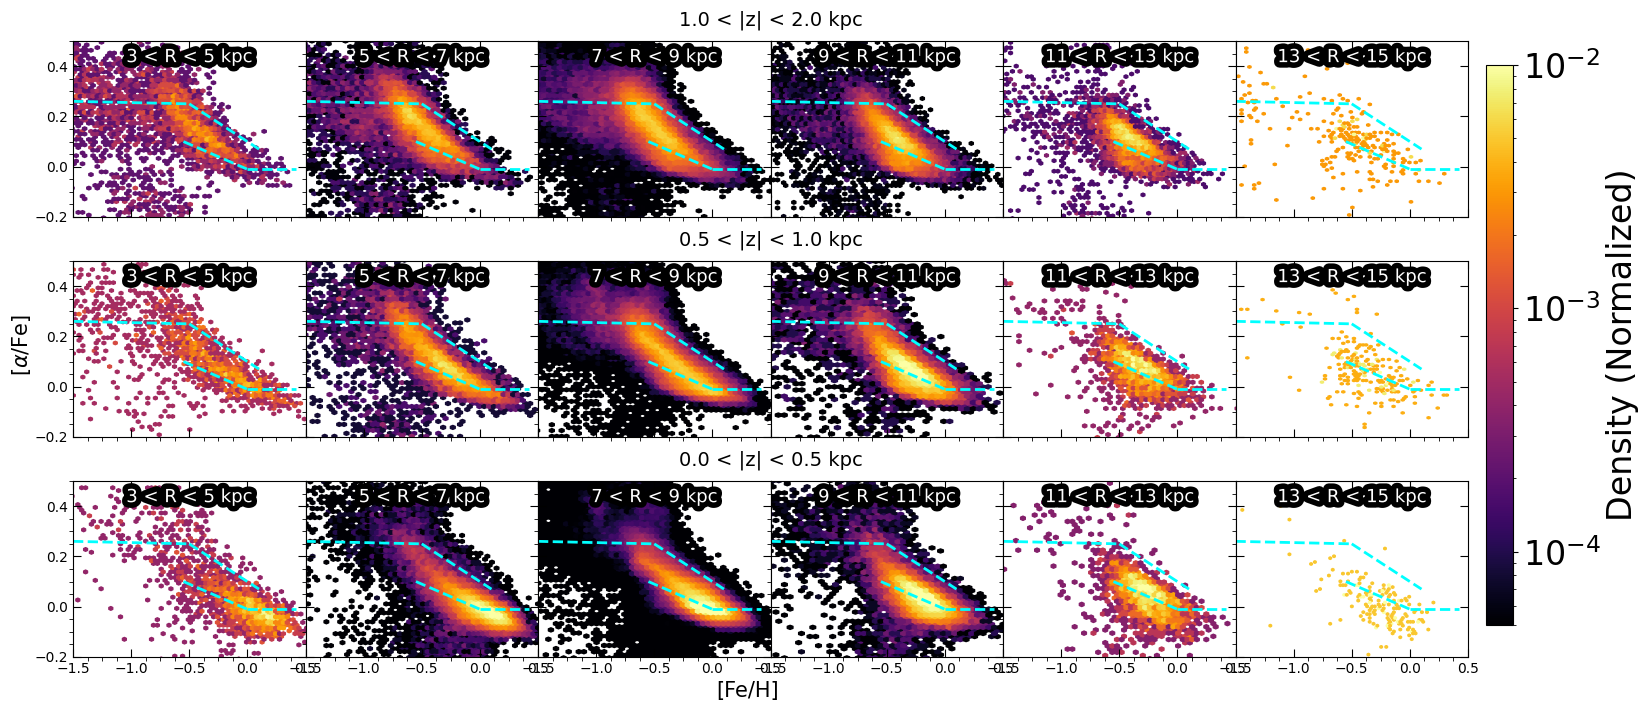

In [8]:
R_bins = [(3,5), (5,7), (7,9), (9,11), (11,13), (13,15)]
z_bins = [(1.0,2.0), (0.5,1.0), (0.0,0.5)]

fig = plt.figure(figsize=(18, 8))

gs = fig.add_gridspec(
    nrows=3, ncols=6,
    hspace=0.25,
    wspace=0.0
)

axes = np.empty((3, 6), dtype=object)

xi = np.linspace(-1.5, 0.5, 100)
yi = np.linspace(-0.2, 0.5, 100)
X, Y = np.meshgrid(xi, yi)

# for plotting cyan lines
def plot_fit(params, color, ax, xmin=-1.5, xmax=0.5):
    m1, m2, xb, yb = params

    x1 = np.linspace(xmin, xb, 100)
    x2 = np.linspace(xb, xmax, 100)

    y1 = yb + m1 * (x1 - xb)
    y2 = yb + m2 * (x2 - xb)

    ax.plot(x1, y1, color=color, lw=2, linestyle='--')
    ax.plot(x2, y2, color=color, lw=2, linestyle='--')
# lines from DR19
top = [-0.01, -0.3, -0.5, 0.25]
bottom = [-0.2, 0., 0, -0.01]


for i, (zmin, zmax) in enumerate(z_bins):
    for j, (Rmin, Rmax) in enumerate(R_bins):

        ax = fig.add_subplot(gs[i, j])
        axes[i, j] = ax

        mask = (
            (R >= Rmin) & (R < Rmax) &
            (np.abs(z) >= zmin) & (np.abs(z) < zmax)
        )

        x = fe_h[mask]
        y = alpha_m[mask]

        if len(x) < 10:
            continue

        weights = np.ones_like(x) / len(x)
        hb = ax.hexbin(
            x, y,
            C=weights,
            reduce_C_function=np.sum,
            gridsize=100,
            cmap='inferno',
            mincnt=1,
            norm=LogNorm(vmin=5e-5, vmax=1e-2)
        )

        plot_fit(top, 'cyan', ax, xmax=0.1)
        plot_fit(bottom, 'cyan', ax, xmin=-0.55, xmax=0.42)

        ax.text(
            0.5, 0.88,
            f"{Rmin} < R < {Rmax} kpc",
            transform=ax.transAxes,
            ha='center',
            fontsize=13,
            color='white',
            path_effects=[
                pe.Stroke(linewidth=8, foreground='black'),
                pe.Normal()
            ]
        )

        ax.set_xlim(-1.5, 0.5)
        ax.set_ylim(-0.2, 0.5)

        ax.tick_params(direction='in', top=True, right=True)

        ax.xaxis.set_minor_locator(AutoMinorLocator(4))
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))

        ax.tick_params(which='major', length=6, labelsize=10)
        ax.tick_params(which='minor', length=3)

        if i < 2:  # not bottom row
            ax.set_xticklabels([])

        if j > 0:  # not first column
            ax.set_yticklabels([])

for i, (zmin, zmax) in enumerate(z_bins):
    row_axes = axes[i, :]
    left = row_axes[0].get_position().x0
    right = row_axes[-1].get_position().x1
    top = row_axes[0].get_position().y1

    fig.text(
        (left + right) / 2,
        top + 0.02,
        f"{zmin} < |z| < {zmax} kpc",
        ha='center',
        fontsize=14
    )

fig.text(0.5, 0.06, r'[Fe/H]', ha='center', fontsize=15)
fig.text(0.09, 0.5, r'[$\alpha$/Fe]', va='center',
         rotation='vertical', fontsize=15)


cax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
cbar = fig.colorbar(hb, cax=cax)
cbar.set_label("Density (Normalized)")
plt.show()

In the above you can see the clear metallicity gradient as you increase Galactic radius, and the shift from the low- to high-$\alpha$ sequence as you increase Galactic height. This demonstrates the BOSS-CLAM parameters accuratly trace the chemical structure of the Milky Way.

## About this notebook

This notebook was create to demonstrate how to use the results from the BOSS-CLAM VAC.

**Authors:** Ilija Medan

**Last Update:** 2026 May 26

If you use `astropy` for published research, please cite the authors. Follow this link for more information about citing `astropy`:
- [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.